In [310]:
import sys
sys.path.insert(0, '../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions


SFREQ_TARGET = 512  # match envelope sampling rate

In [311]:
participants = pd.read_csv(SNHL_ROOT / 'participants.tsv', sep='\t')
participants.head()

,participant_id,age,hearing_status,ear_eeg,handedness,gender,speech_reception_thresholds,digit_span_backward,digit_span_forward,FT_test_temporal,...,audiogram_right_ear_8000Hz,audiogram_left_ear_125Hz,audiogram_left_ear_250Hz,audiogram_left_ear_500Hz,audiogram_left_ear_1000Hz,audiogram_left_ear_2000Hz,audiogram_left_ear_3000Hz,audiogram_left_ear_4000Hz,audiogram_left_ear_6000Hz,audiogram_left_ear_8000Hz
0,sub-001,71,hi,Yes,L,M,-1.900000,19,23,8.560636,...,90,20,15,15,20,45,70,80,80,75
1,sub-002,56,hi,Yes,L,F,-3.066667,10,16,-1.592565,...,85,15,10,10,25,50,75,80,90,85
2,sub-003,66,hi,Yes,R,M,-3.266667,11,16,-0.238726,...,95,15,10,5,10,20,50,80,80,80
3,sub-004,74,hi,Yes,R,F,-2.966667,12,27,-1.734571,...,65,25,10,10,10,15,25,40,60,70
4,sub-005,70,hi,Yes,R,M,-2.533333,16,18,3.190100,...,75,10,15,15,25,40,60,50,65,80


In [312]:
nh_subjects = participants[participants['hearing_status'] == 'nh']['participant_id'].tolist()
hi_subjects = participants[participants['hearing_status'] == 'hi']['participant_id'].tolist()

print("NH SUBJECTS: ", nh_subjects)
print("HI SUBJECTS:", hi_subjects)

NH SUBJECTS:  ['sub-021', 'sub-022', 'sub-023', 'sub-024', 'sub-025', 'sub-026', 'sub-027', 'sub-028', 'sub-029', 'sub-030', 'sub-031', 'sub-032', 'sub-033', 'sub-034', 'sub-035', 'sub-036', 'sub-037', 'sub-038', 'sub-039', 'sub-040', 'sub-043', 'sub-044']
HI SUBJECTS: ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018', 'sub-019', 'sub-020', 'sub-041', 'sub-042']


In [313]:
def load_eeg(subject_id):
    bdf_path = SNHL_ROOT / subject_id / 'eeg' / f'{subject_id}_task-selectiveattention_eeg.bdf'
    raw = mne.io.read_raw_bdf(str(bdf_path), preload=True)

    raw.set_eeg_reference(['EXG1', 'EXG2'])
    raw.drop_channels(['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8'])
    raw.pick_types(eeg=True)  # drop stim channel early too
    
    raw.resample(64)          # downsample first → fewer samples to filter
    raw.filter(0.5, 20.0)     # then filter at 64 Hz

    return raw

In [314]:
def get_trials(subject_id):
    tsv_path = SNHL_ROOT / subject_id / 'eeg' / f'{subject_id}_task-selectiveattention_events.tsv'
    events = pd.read_csv(tsv_path, sep='\t')

    targets  = events[events['trigger_type'] == 'targetonset'].reset_index(drop=True)
    ends     = events[events['trigger_type'] == 'trialend'].reset_index(drop=True)
    maskers  = events[events['trigger_type'] == 'maskeronset'].reset_index(drop=True)

    # Build trial table
    trials = targets.copy()
    trials['end_sample'] = ends['sample'].values
    trials['end_onset']  = ends['onset'].values
    trials['difficulty'] = ends['diffulty_ratings'].values
    trials['score']      = ends['questionnaire_scores'].values

    # Add masker info
    two_talker_mask = trials['single_talker_two_talker'] == 'twotalker'
    trials.loc[two_talker_mask, 'masker_stim_file']  = maskers['stim_file'].values
    trials.loc[two_talker_mask, 'masker_sample']     = maskers['sample'].values
    trials.loc[two_talker_mask, 'masker_onset']      = maskers['onset'].values

    return trials[two_talker_mask].reset_index(drop=True)

In [315]:
def load_envelope_ndvar(mat_path):
    mat = scipy.io.loadmat(str(mat_path))["dat"]
    
    feat = mat['feat'][0][0].squeeze()   # 1D envelope
    #print("feat:", feat)
    fs = mat['fs'][0][0][0][0]
    t    = mat['t'][0][0].squeeze()      # time vector re trial onset
    #print("t: ", t)
    
    # Build Eelbrain time dimension from the t vector
    time_dim = eelbrain.UTS(t[0], 1/fs, len(feat))
    
    
    env = eelbrain.NDVar(feat, dims=(time_dim,), name='envelope')
    env = eelbrain.resample(env, 64)
    return env


def load_trial_envelopes(subject_id, trial, is_hi=False):
    
    subject = subject_id.replace('-', '') # change subject_id from "sub-001" -> "sub001"

    sub_stim_dir = SNHL_STIMULUS_DIR / subject

    # Extract trial number from stim_file (e.g. 'sub001/target/t004.wav' → 't004')
    trial_num = Path(trial['stim_file']).stem  # e.g. 't004'
    masker_num = Path(trial['masker_stim_file']).stem  # e.g. 'm004'

    # For HI subjects: use 'woa' files (without CamEQ) to match NH
    suffix = "woa" if is_hi else ""
    
    target_path = sub_stim_dir / 'target' / f'{trial_num}{suffix}.mat'
    masker_path = sub_stim_dir / 'masker' / f'{masker_num}{suffix}.mat'

    env_attended = load_envelope_ndvar(target_path)
    env_ignored  = load_envelope_ndvar(masker_path)

    return env_attended, env_ignored

In [316]:
def eeg_trial_to_ndvar(raw, trial, trf_sensor_dim):
    sfreq = raw.info['sfreq']
    start_sample = int(trial['sample']     / (512 / sfreq))  # target onset
    end_sample   = int(trial['end_sample'] / (512 / sfreq))

    data = raw.get_data(start=start_sample, stop=end_sample)
    data = data * 1e6

    order = [raw.ch_names.index(ch) for ch in trf_sensor_dim.names]
    data  = data[order, :]

    # Time axis starts at 0 = target onset, matching envelope t vectors
    time_dim = eelbrain.UTS(0.0, 1/sfreq, data.shape[1])
    return eelbrain.NDVar(data, dims=(trf_sensor_dim, time_dim), name='eeg')

In [317]:
def process_subject(subject_id, trf_sensor_dim, is_hi=False):
    print(f"Processing subject {subject_id} " + "-" * 50)
    
    raw = load_eeg(subject_id)
    print(f"  EEG: {len(raw.ch_names)} channels, {raw.info['sfreq']} Hz, {raw.times[-1]:.1f}s total")
    
    trials = get_trials(subject_id)
    print(f"  {len(trials)} two-talker trials found")
    
    trial_data = []
    for _, trial in trials.iterrows():
        trial_name = Path(trial['stim_file']).stem
        try:
            eeg                       = eeg_trial_to_ndvar(raw, trial, trf_sensor_dim)
            env_attended, env_ignored = load_trial_envelopes(subject_id, trial, is_hi)

            # Both EEG and envelopes share the same t=0 (target onset)
            t_start = float(env_ignored.time.tmin)   # masker delay (~4s)
            t_stop  = min(float(eeg.time.tmax),
                        float(env_attended.time.tmax),
                        float(env_ignored.time.tmax))

            eeg_trimmed = eeg.sub(time=(t_start, t_stop))
            att_trimmed = env_attended.sub(time=(t_start, t_stop))
            ign_trimmed = env_ignored.sub(time=(t_start, t_stop))

            # Final sample-level alignment
            n_samples   = min(eeg_trimmed.shape[-1], att_trimmed.shape[-1], ign_trimmed.shape[-1])
            eeg_trimmed = eeg_trimmed.sub(time=(t_start, eeg_trimmed.time[n_samples-1]))
            att_trimmed = att_trimmed.sub(time=(t_start, att_trimmed.time[n_samples-1]))
            ign_trimmed = ign_trimmed.sub(time=(t_start, ign_trimmed.time[n_samples-1]))

            trial_data.append({
                'subject':     subject_id,
                'group':       'HI' if is_hi else 'NH',
                'trial':       trial['stim_file'],
                'eeg':         eeg_trimmed,
                'attended':    att_trimmed,
                'ignored':     ign_trimmed,
                'attend_side': trial['attend_left_right'],
                'difficulty':  trial['difficulty'],
                'score':       trial['score'],
            })
        except Exception as e:
            print(f"  Skipping {trial_name}: {e}")
    
    print(f"\n  ✓ {len(trial_data)}/{len(trials)} trials processed")
    return trial_data

In [318]:
# Load your pre-trained backward TRF from the other dataset
name = helper_functions.get_trf_model_name(
        DATASET_TYPE.FUGLSANG, PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, generalised=GENERALISATION_TYPE.AVERAGE
    )

trf = eelbrain.load.unpickle(FUGLSANG_GENERAL_TRF_DIR / f'full_{name}.pickle')

def decode_attention(trial_data, trf):
    eeg      = trial_data['eeg']
    att_env  = trial_data['attended']
    ign_env  = trial_data['ignored']
    
    decision, r_att, r_ign = helper_functions.aad_single_classifier(eeg, true_att=att_env, true_ign=ign_env, trf=trf)
    
    return decision, r_att, r_ign

In [319]:
name = helper_functions.get_trf_model_name(
        DATASET_TYPE.FUGLSANG, PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, generalised=GENERALISATION_TYPE.AVERAGE
    )

trf = eelbrain.load.unpickle(FUGLSANG_GENERAL_TRF_DIR / f'full_{name}.pickle')

#trial_data = process_subject(nh_subjects[1], trf.h_scaled.sensor)

In [321]:
results = []

for subject in hi_subjects:
    trial_data = process_subject(subject, trf.h_scaled.sensor, is_hi=True)
    for trial in trial_data:
        decision, r_att, r_ign = decode_attention(trial, trf)
        print(f"  {trial["trial"]}: r_att={float(r_att):.4f}, r_ign={float(r_ign):.4f}")
        results.append({
            'subject':     trial['subject'],
            'group':       trial['group'],
            'trial':       trial['trial'],
            'attend_side': trial['attend_side'],
            'difficulty':  trial['difficulty'],
            'score':       trial['score'],
            'r_att':       float(r_att),
            'r_ign':       float(r_ign),
            'delta_r':     float(r_att) - float(r_ign),
            'correct':     bool(decision),
        })

results_df = pd.DataFrame(results)
results_df.to_csv('results_hi.csv', index=False)

# Summary
acc   = results_df['correct'].mean()
r_att = results_df['r_att'].mean()
r_ign = results_df['r_ign'].mean()
print(f"r_att: {r_att:.4f} | r_ign: {r_ign:.4f} | acc: {acc:.2%}")

Processing subject sub-001 --------------------------------------------------
  EEG: 64 channels, 64.0 Hz, 5585.0s total
  32 two-talker trials found

  ✓ 32/32 trials processed
  sub001/target/t004.wav: r_att=0.1200, r_ign=0.0176
  sub001/target/t006.wav: r_att=0.0147, r_ign=0.0061
  sub001/target/t007.wav: r_att=0.0603, r_ign=0.0144
  sub001/target/t008.wav: r_att=0.1196, r_ign=0.0240
  sub001/target/t009.wav: r_att=0.0742, r_ign=0.0048
  sub001/target/t010.wav: r_att=0.1028, r_ign=0.0028
  sub001/target/t011.wav: r_att=0.1536, r_ign=0.0576
  sub001/target/t012.wav: r_att=0.0773, r_ign=0.0523
  sub001/target/t015.wav: r_att=0.0022, r_ign=0.0713
  sub001/target/t016.wav: r_att=0.0443, r_ign=0.0332
  sub001/target/t018.wav: r_att=0.0322, r_ign=0.0984
  sub001/target/t019.wav: r_att=0.0592, r_ign=0.0879
  sub001/target/t021.wav: r_att=0.1087, r_ign=0.0376
  sub001/target/t022.wav: r_att=0.2034, r_ign=0.0921
  sub001/target/t023.wav: r_att=0.0521, r_ign=0.0006
  sub001/target/t024.wav: r

In [332]:
results = []

for subject in nh_subjects:
    trial_data = process_subject(subject, trf.h_scaled.sensor, is_hi=False)
    for trial in trial_data:
        decision, r_att, r_ign = decode_attention(trial, trf)
        print(f"  {trial["trial"]}: r_att={float(r_att):.4f}, r_ign={float(r_ign):.4f}")
        results.append({
            'subject':     trial['subject'],
            'group':       trial['group'],
            'trial':       trial['trial'],
            'attend_side': trial['attend_side'],
            'difficulty':  trial['difficulty'],
            'score':       trial['score'],
            'r_att':       float(r_att),
            'r_ign':       float(r_ign),
            'delta_r':     float(r_att) - float(r_ign),
            'correct':     bool(decision),
        })

results_df = pd.DataFrame(results)
results_df.to_csv('results_nh.csv', index=False)

# Summary
acc   = results_df['correct'].mean()
r_att = results_df['r_att'].mean()
r_ign = results_df['r_ign'].mean()
print(f"r_att: {r_att:.4f} | r_ign: {r_ign:.4f} | acc: {acc:.2%}")

Processing subject sub-021 --------------------------------------------------
  EEG: 64 channels, 64.0 Hz, 5790.0s total
  32 two-talker trials found

  ✓ 32/32 trials processed
  sub021/target/t002.wav: r_att=0.0652, r_ign=0.0696
  sub021/target/t003.wav: r_att=0.1518, r_ign=0.0547
  sub021/target/t004.wav: r_att=0.0150, r_ign=0.0595
  sub021/target/t005.wav: r_att=0.0568, r_ign=0.0072
  sub021/target/t007.wav: r_att=0.1507, r_ign=0.0039
  sub021/target/t008.wav: r_att=0.0308, r_ign=0.0120
  sub021/target/t011.wav: r_att=0.0935, r_ign=0.0385
  sub021/target/t012.wav: r_att=0.0155, r_ign=0.0090
  sub021/target/t015.wav: r_att=0.0273, r_ign=0.0647
  sub021/target/t016.wav: r_att=0.1473, r_ign=0.0695
  sub021/target/t017.wav: r_att=0.0910, r_ign=0.0836
  sub021/target/t018.wav: r_att=0.0563, r_ign=0.0810
  sub021/target/t019.wav: r_att=0.0675, r_ign=0.0651
  sub021/target/t020.wav: r_att=0.0751, r_ign=0.0354
  sub021/target/t022.wav: r_att=0.1013, r_ign=0.0175
  sub021/target/t024.wav: r

In [335]:
def plot_scatter_panel(ax, df, color, title):

    r_att   = df['r_att'].values
    r_ign   = df['r_ign'].values
    correct = r_att > r_ign
    acc     = correct.mean()
    labels  = df['subject'].str.replace('sub-', '').values

    ax.scatter(r_att[correct],  r_ign[correct],
               color=color, edgecolors='white', linewidths=0.5,
               s=65, zorder=3, marker='o', label=f'Correct ({acc:.0%})')
    ax.scatter(r_att[~correct], r_ign[~correct],
               color=color, edgecolors='red', linewidths=0.8,
               s=65, zorder=3, marker='o', label=f'Incorrect ({1-acc:.0%})')

    for s, x, y in zip(labels, r_att, r_ign):
        ax.annotate(s, (x, y),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=6.5, color=color, alpha=0.85)

    all_r = np.concatenate([r_att, r_ign])
    lim   = [-0.05, max(all_r) * 1.2]
    ax.plot(lim, lim, 'k--', linewidth=0.9, alpha=0.5, zorder=2)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$r_{att}$', fontsize=9)
    ax.set_ylabel(r'$r_{ign}$', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7.5, loc='upper left', framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

In [337]:
def plot_scatter_panel(ax, df, color, title):

    subjects  = df.groupby('subject')[['r_att', 'r_ign', 'correct']].mean()
    r_att     = subjects['r_att'].values
    r_ign     = subjects['r_ign'].values
    correct   = r_att > r_ign
    acc       = correct.mean()
    sub_names = subjects.index.tolist()

    ax.scatter(r_att[correct],  r_ign[correct],
               color=color, edgecolors='white', linewidths=0.5,
               s=65, zorder=3, marker='o', label=f'Correct ({acc:.0%})')
    ax.scatter(r_att[~correct], r_ign[~correct],
               color=color, edgecolors='red', linewidths=0.8,
               s=65, zorder=3, marker='o', label=f'Incorrect ({1-acc:.0%})')

    for s, x, y in zip(sub_names, r_att, r_ign):
        ax.annotate(s.replace('sub-', ''), (x, y),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=6.5, color=color, alpha=0.85)

    all_r = np.concatenate([r_att, r_ign])
    lim   = [-0.05, max(all_r) * 1.2]
    ax.plot(lim, lim, 'k--', linewidth=0.9, alpha=0.5, zorder=2)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$r_{att}$', fontsize=9)
    ax.set_ylabel(r'$r_{ign}$', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7.5, loc='upper left', framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

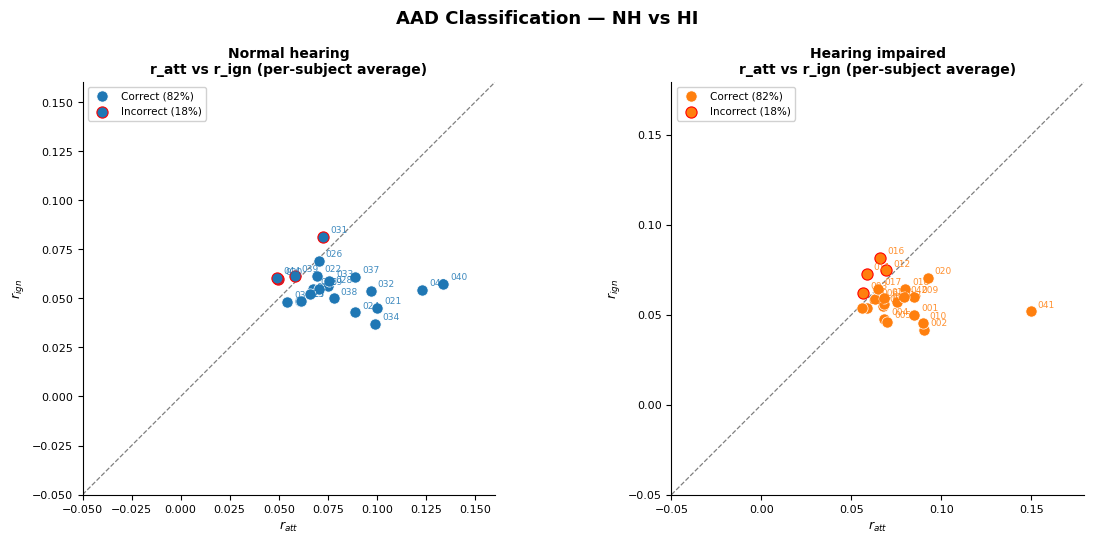

In [338]:
results_nh = pd.read_csv('results_nh.csv')
results_hi = pd.read_csv('results_hi.csv')

fig, (ax_nh, ax_hi) = plt.subplots(1, 2, figsize=(12, 5.5))

plot_scatter_panel(
    ax_nh, results_nh,
    color='tab:blue',
    title='Normal hearing\nr_att vs r_ign (per-subject average)',
)
plot_scatter_panel(
    ax_hi, results_hi,
    color='tab:orange',
    title='Hearing impaired\nr_att vs r_ign (per-subject average)',
)

fig.suptitle('AAD Classification — NH vs HI', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / 'aad_scatter_nh_hi.png', dpi=150, bbox_inches='tight')
plt.show()

# Testing and look at data

In [ ]:
testing_subject = hi_subjects[0]
testing_subject

'sub-001'

In [ ]:
eeg = load_eeg(testing_subject)

In [ ]:
len(eeg.ch_names), eeg.ch_names

(64,
 ['Fp1',
  'AF7',
  'AF3',
  'F1',
  'F3',
  'F5',
  'F7',
  'FT7',
  'FC5',
  'FC3',
  'FC1',
  'C1',
  'C3',
  'C5',
  'T7',
  'TP7',
  'CP5',
  'CP3',
  'CP1',
  'P1',
  'P3',
  'P5',
  'P7',
  'P9',
  'PO7',
  'PO3',
  'O1',
  'Iz',
  'Oz',
  'POz',
  'Pz',
  'CPz',
  'Fpz',
  'Fp2',
  'AF8',
  'AF4',
  'AFz',
  'Fz',
  'F2',
  'F4',
  'F6',
  'F8',
  'FT8',
  'FC6',
  'FC4',
  'FC2',
  'FCz',
  'Cz',
  'C2',
  'C4',
  'C6',
  'T8',
  'TP8',
  'CP6',
  'CP4',
  'CP2',
  'P2',
  'P4',
  'P6',
  'P8',
  'P10',
  'PO8',
  'PO4',
  'O2'])

In [ ]:
trials = get_trials(testing_subject)
trials.head(7)

,onset,duration,sample,type,value,trigger_type,stim_file,attend_left_right,single_talker_two_talker,attend_male_female,stim_file_without_cambridge_eq,diffulty_ratings,questionnaire_scores,end_sample,end_onset,difficulty,score,masker_stim_file,masker_sample,masker_onset
0,374.923828,NaN,191962,STATUS,240.0,targetonset,sub001/target/t004.wav,attendleft,twotalker,attendmale,sub001/target/t004woa.wav,NaN,NaN,218576,426.904297,24.0,75.0,sub001/masker/m004.wav,193955.0,378.816406
1,598.503906,NaN,306435,STATUS,240.0,targetonset,sub001/target/t006.wav,attendleft,twotalker,attendmale,sub001/target/t006woa.wav,NaN,NaN,332029,648.492188,24.0,75.0,sub001/masker/m006.wav,308503.0,602.542969
2,708.189453,NaN,362594,STATUS,255.0,targetonset,sub001/target/t007.wav,attendright,twotalker,attendmale,sub001/target/t007woa.wav,NaN,NaN,391153,763.968750,26.0,100.0,sub001/masker/m007.wav,364405.0,711.726562
3,819.101562,NaN,419381,STATUS,240.0,targetonset,sub001/target/t008.wav,attendleft,twotalker,attendmale,sub001/target/t008woa.wav,NaN,NaN,447196,873.427734,26.0,100.0,sub001/masker/m008.wav,421268.0,822.787109
4,939.400391,NaN,480974,STATUS,255.0,targetonset,sub001/target/t009.wav,attendright,twotalker,attendmale,sub001/target/t009woa.wav,NaN,NaN,506568,989.388672,25.0,100.0,sub001/masker/m009.wav,482545.0,942.468750
5,1051.921875,NaN,538585,STATUS,240.0,targetonset,sub001/target/t010.wav,attendleft,twotalker,attendmale,sub001/target/t010woa.wav,NaN,NaN,564325,1102.195312,26.0,50.0,sub001/masker/m010.wav,540566.0,1055.791016
6,1168.703125,NaN,598377,STATUS,255.0,targetonset,sub001/target/t011.wav,attendright,twotalker,attendmale,sub001/target/t011woa.wav,NaN,NaN,625671,1222.011719,26.0,100.0,sub001/masker/m011.wav,600120.0,1172.107422


In [ ]:
trial = trials.iloc[0]
print(f"    masker_sample (original 512Hz): {trial['masker_sample']}")
print(f"    masker_sample (resampled 64Hz): {int(trial['masker_sample'] / (512/64))}")
print(f"    end_sample (resampled 64Hz):    {int(trial['end_sample'] / (512/64))}")

    masker_sample (original 512Hz): 193955.0
    masker_sample (resampled 64Hz): 24244
    end_sample (resampled 64Hz):    27322


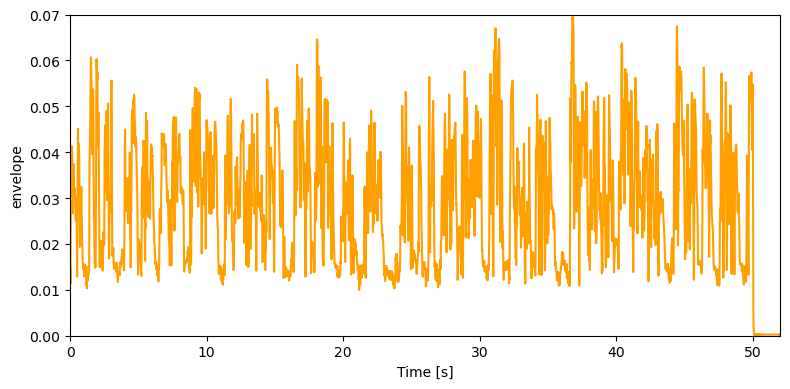

In [ ]:
# 1st trial
env = load_envelope_ndvar("/Users/sylvestereley/Data/Beyond-TRFs/ds-eeg-snhl/derivatives/stimuli/sub001/target/t004woa.mat")
uts_plot = eelbrain.plot.UTS(env)

In [ ]:
env_att, env_ign = load_trial_envelopes(testing_subject, trials.iloc[0], is_hi=True)
trials.iloc[0].stim_file, env_att.time, env_ign.time # see ignored (masker) starts later

('sub001/target/t004.wav',
 UTS(0.0, 0.015625, 3328),
 UTS(3.892578125, 0.015625, 3328))

In [ ]:
name = helper_functions.get_trf_model_name(DATASET_TYPE.FUGLSANG, PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, generalised=GENERALISATION_TYPE.AVERAGE)

trf = eelbrain.load.unpickle(FUGLSANG_GENERAL_TRF_DIR / f'full_{name}.pickle')

eeg_ndvar = eeg_trial_to_ndvar(eeg, trials.iloc[0], trf.h_scaled.sensor)
eeg_ndvar, eeg_ndvar.time

(<NDVar 'eeg': 64 sensor, 3078 time>, UTS(0.0, 0.015625, 3078))

In [ ]:
trial_data = process_subject(testing_subject, trf.h_scaled.sensor)

Processing subject sub-001 ----------------------------------------------------------
Loading EEG...
  EEG: 64 channels, 64.0 Hz, 5585.0s total
Loading trials...
  32 two-talker trials found

  Trial t004 ---
    EEG:      <NDVar 'eeg': 64 sensor, 3078 time>
    Attended: <NDVar 'envelope': 3328 time>
    Ignored:  <NDVar 'envelope': 3328 time>
    Trimming: t_start=3.893s  t_stop=48.078s  duration=44.186s
    After trim — EEG: (64, 2826), att: (2826,), ign: (2826,)
    Attended envelope — mean: 0.0453, std: 0.0224
    Ignored  envelope — mean: 0.0474, std: 0.0187
    EEG — mean: -0.0000, std: 0.0000

  Trial t006 ---
    EEG:      <NDVar 'eeg': 64 sensor, 2941 time>
    Attended: <NDVar 'envelope': 3200 time>
    Ignored:  <NDVar 'envelope': 3200 time>
    Trimming: t_start=4.039s  t_stop=45.938s  duration=41.898s
    After trim — EEG: (64, 2680), att: (2680,), ign: (2680,)
    Attended envelope — mean: 0.0451, std: 0.0214
    Ignored  envelope — mean: 0.0471, std: 0.0180
    EEG — me

In [ ]:
trial_data[0]

{'subject': 'sub-004',
 'group': 'NH',
 'trial': 'sub004/target/t002.wav',
 'eeg': <NDVar 'eeg': 64 sensor, 2928 time>,
 'attended': <NDVar 'envelope': 2928 time>,
 'ignored': <NDVar 'envelope': 2928 time>,
 'attend_side': 'attendright',
 'difficulty': 34.0,
 'score': 75.0}